# **YouComments**

Генератор комментариев для `YouTube`. \
Рекомендую использовать на англоязычных видео (с включенным впн).  

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
import cv2
import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tr
from torchvision.transforms import InterpolationMode

%matplotlib inline

/home/kwampek/global_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2-large")

special_tokens = {
    "additional_special_tokens": ["<META>", "<TEXT>", "<REPLY>"]
}

tokenizer.add_special_tokens(special_tokens)
tokenizer.pad_token = tokenizer.eos_token

for text in special_tokens["additional_special_tokens"]:
    print(text, " : ", tokenizer.convert_tokens_to_ids(text))

text_token_id = tokenizer.convert_tokens_to_ids("<TEXT>")


model = GPT2LMHeadModel.from_pretrained("gpt2-large")
model.resize_token_embeddings(len(tokenizer))


<META>  :  50257
<TEXT>  :  50258
<REPLY>  :  50259


Loading weights: 100%|██████████| 436/436 [00:00<00:00, 14613.48it/s]


Embedding(50260, 1280)

In [7]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50260, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)


In [8]:
from sklearn.model_selection import train_test_split

def merge_comments_replies(comments_path="comments.csv", replies_path="replies.csv", test_size=0.2):
    need_columns = ['video_title','video_description','channel_title','channel_description','comment_id', 'author', 'comment_text']

    df_comments = pd.read_csv(comments_path)[need_columns].fillna("")

    comments_train, comments_test = train_test_split(df_comments, test_size=test_size, random_state=42)

    df_replies = pd.read_csv(replies_path)[['parent_id','reply_text']].fillna("")

    df_train = df_replies.merge(
        comments_train,
        left_on="parent_id",
        right_on="comment_id",
        how="left",
        suffixes=(None, None)
    )

    df_test = df_replies.merge(
        comments_test,
        left_on="parent_id",
        right_on="comment_id",
        how="left",
        suffixes=(None, None)
    )

    return df_train, df_test


df, df_small = merge_comments_replies(
    comments_path="comments.csv", 
    replies_path="replies.csv",
    test_size=0.4
)

print(df.shape)

df_train, df_test = train_test_split(df_small, test_size=0.2, random_state=42)

print(df_train.shape, df_test.shape)

(26389, 9)
(11348, 9) (2838, 9)


# **Датасет**

Собран из комментариев и ответов на них для 144 видео из трендов (к сожалению YouTube не хотел отдавать больше). После `join` (объединения комментариев и соответсвтующих им ответов), датасет стал иметь `26389` записей, из которых использовал только половину.  

Input пришлось обрезать из-за очень малого размера оперативной памяти. Поэтому иногда встречаются обрезанные комментарии. 

In [10]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# video_title,video_description,channel_title,channel_description,comment_text,likes,author

special_tokens = {
    "additional_special_tokens": ["<META>", "<TEXT>", "<REPLY>"]
}

import torch
from torch.utils.data import Dataset

class SteroidDataset(Dataset):
    def __init__(self, df, tokenizer,
                 max_title_tokens=20,
                 max_desc_tokens=50,
                 max_comment_tokens=50,
                 max_reply_tokens=50):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer

        self.max_title = max_title_tokens
        self.max_desc = max_desc_tokens
        self.max_comment = max_comment_tokens
        self.max_reply = max_reply_tokens

        self.meta_id = tokenizer.convert_tokens_to_ids("<META>")
        self.text_id = tokenizer.convert_tokens_to_ids("<TEXT>")
        self.reply_id = tokenizer.convert_tokens_to_ids("<REPLY>")
        self.newline_id = tokenizer.encode("\n", add_special_tokens=False)[0]
        self.colon_id = tokenizer.encode(":", add_special_tokens=False)[0]

    def _tokenize_and_truncate(self, text, max_len):
        text = str(text) if text else ""
        tokens = self.tokenizer.encode(text, add_special_tokens=False)
        return tokens[:max_len]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = [self.meta_id, self.newline_id]

        def add_field(name, text, max_len):
            seq.extend(self.tokenizer.encode(f"{name}:", add_special_tokens=False))
            seq.append(self.colon_id)
            seq.extend(self._tokenize_and_truncate(text, max_len))
            seq.append(self.newline_id)

        add_field("Video Title", row.get('video_title', ""), self.max_title)
        add_field("Video Description", row.get('video_description', ""), self.max_desc)
        add_field("Channel Title", row.get('channel_title', ""), self.max_title)
        add_field("Channel Description", row.get('channel_description', ""), self.max_desc)

        seq.append(self.text_id)
        seq.append(self.newline_id)
        seq.extend(self._tokenize_and_truncate(row.get('comment_text', ""), self.max_comment))
        seq.append(self.newline_id)

        seq.append(self.reply_id)
        seq.append(self.newline_id)
        seq.extend(self._tokenize_and_truncate(row.get('reply_text', ""), self.max_reply))

        input_ids = torch.tensor(seq, dtype=torch.long)
        attention_mask = torch.ones_like(input_ids)
        labels = input_ids.clone()

        reply_pos = (input_ids == self.reply_id).nonzero(as_tuple=True)[0]
        if len(reply_pos) > 0:
            labels[:reply_pos[0] + 1] = -100
        else:
            labels[:] = -100

        return input_ids, attention_mask, labels

    def __len__(self):
        return len(self.df)

In [11]:
dataset_train = SteroidDataset(
    df=df_train,
    tokenizer=tokenizer
)

dataset_test = SteroidDataset(
    df=df_test,
    tokenizer=tokenizer
)

vocab_size = len(tokenizer)
hidden_size = 1280

In [12]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    input_ids_list = [item[0] for item in batch]
    attention_mask_list = [item[1] for item in batch]
    labels_list = [item[2] for item in batch]

    input_ids = pad_sequence(
        input_ids_list,
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

    attention_mask = pad_sequence(
        attention_mask_list,
        batch_first=True,
        padding_value=0
    )

    labels = pad_sequence(
        labels_list,
        batch_first=True,
        padding_value=-100
    )

    return [input_ids, attention_mask, labels]

In [13]:
batch_size = 4
num_workers = 0

dataloader_train = DataLoader(
    dataset=dataset_train,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)


dataloader_test = DataLoader(
    dataset=dataset_test,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)

# **Модель**

Использовал несколько подходов:
1) LoRa 
2) LoRa + 5 последних размороженных слоев
3) LoRa + половина размороженных слоев
4) половина размороженных слоев

К сожалению, модели изначально были обучены на некачественном датасете со смайликами. Новый датасет успел обучить только с LoRa. Во всех подходах не удалось значительно улучшить `accuracy` модели.

In [14]:
import torch
from torch import nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from peft import LoraConfig, get_peft_model, TaskType

class SteroidGPT(nn.Module):
    def __init__(self, lora_config=None, first_rg_layer_num=18, hidden_size=1280):
        super().__init__()
        
        self.tokenizer = GPT2Tokenizer.from_pretrained("gpt2-large")
        self.tokenizer.add_special_tokens(special_tokens)
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = GPT2LMHeadModel.from_pretrained("gpt2-large")
        self.model.resize_token_embeddings(len(self.tokenizer))

        for i, block in enumerate(self.model.transformer.h):
            if i < first_rg_layer_num:
                for param in block.parameters():
                    param.requires_grad = False

        for i, block in enumerate(self.model.transformer.h):
            if i >= first_rg_layer_num:
                for param in block.parameters():
                    param.requires_grad = True

        if lora_config:
            self.model = get_peft_model(self.model, lora_config)

        self.hidden_size = hidden_size

    def forward(self, input_ids, attention_mask, labels=None):
        """
        input_ids: [B, seq_len] от DataLoader
        attention_mask: [B, seq_len]
        labels: [B, seq_len]
        """
        
        return self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

    @torch.no_grad()
    def generate_from_batch(self, input_ids, attention_mask, max_new_tokens=200, temperature=0.8, top_p=0.9):
        """
        Генерация комментариев из батча embeddings (совместимо с DataLoader)
        batch_inputs_embeds: [B, seq_len, hidden_size] от SteroidDataset
        """
        self.model.eval()
        generated_ids = self.model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            no_repeat_ngram_size=3,
            eos_token_id=self.tokenizer.eos_token_id
        )

        generated_only = generated_ids[:, input_ids.size(1):]
        decoded = [self.tokenizer.decode(ids, skip_special_tokens=True) for ids in generated_only]
        return decoded

In [15]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def create_model_and_optimizer(model_class, model_params, optim_params, device=device):
    model = model_class(**model_params)
    model = model.to(device)
    
    optimizer = torch.optim.Adam(
        model.parameters(),
        **optim_params
    )
    return model, optimizer


In [2]:
# device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# lora_config = LoraConfig(
#     task_type=TaskType.CAUSAL_LM,
#     r=8,
#     lora_alpha=16,
#     lora_dropout=0.1,
#     target_modules=["c_attn", "c_proj", "c_fc"],
#     bias="none"
# )

# ONLY_LORA = 36

# model_params = {
#     'lora_config':lora_config,
#     'first_rg_layer_num':ONLY_LORA,
#     'hidden_size':1280,
# }

# optim_params = {
#     'lr': 1e-4,
#     'weight_decay': 0.01,
#     'betas': (0.9, 0.999)
# }

# model, optimizer = create_model_and_optimizer(
#     SteroidGPT,
#     model_params,
#     optim_params,
#     device
# )



# **Обучение**

In [16]:
from collections import defaultdict


def train(model, optimizer, loader, criterion):
    model.train()
    losses_tr = []
    for batch_inputs_ids, batch_attention_mask, batch_labels in tqdm(loader):
        batch_inputs_ids = batch_inputs_ids.to(device)
        batch_attention_mask = batch_attention_mask.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        pred = model(batch_inputs_ids, batch_attention_mask, batch_labels)
        loss = pred.loss
        
        loss.backward()
        optimizer.step()
        losses_tr.append(loss.item())
    
    return model, optimizer, np.mean(losses_tr)


def val(model, loader, criterion=None, metric_names=None):
    model.eval()
    losses_val = []

    if metric_names is not None:
        metrics = defaultdict(list)

    with torch.no_grad():
        for batch_inputs_ids, batch_attention_mask, batch_labels in tqdm(loader):
            batch_inputs_ids = batch_inputs_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)

            res = model(batch_inputs_ids, batch_attention_mask, batch_labels)

            loss = res.loss
            logits = res.logits

            losses_val.append(loss.item())

            mask = batch_labels != -100

            logits_masked = logits[mask]
            target = batch_labels[mask]

            if metric_names is not None:
                if 'accuracy' in metric_names:
                    max_k = max(metric_names["accuracy"]["top"])
                    topk = torch.topk(logits_masked, k=max_k, dim=-1).indices  # [N, K]

                    for k in metric_names["accuracy"]["top"]:
                        topk_preds = topk[:, :k]  # [N, k]

                        acc = (topk_preds == target.unsqueeze(1)).any(dim=1).float().mean()

                        metrics[f'accuracy ~ top#{k}'].append(acc.item())

    if metric_names is not None:
        for name in metrics:
            metrics[name] = np.mean(metrics[name])

    return np.mean(losses_val), metrics if metric_names else None

In [17]:
from IPython.display import clear_output
import warnings
import time
from datetime import timedelta

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']


def learning_loop(
    model,
    optimizer,
    train_loader,
    val_loader,
    criterion,
    scheduler=None,
    min_lr=None,
    epochs=60,
    val_every=1,
    draw_every=1,
    separate_show=False,
    model_name=None,
    chkp_folder="./chkps",
    metric_names=None,
):
    # Выбираем куда будем сохранять модель
    if model_name is None:
        if os.path.exists(chkp_folder):
            num_starts = len(os.listdir(chkp_folder)) + 1
        else:
            num_starts = 1
        model_name = f'model#{num_starts}'
    else:
        if "#" not in model_name:
            model_name += "#0"
    changed = False
    while os.path.exists(os.path.join(chkp_folder, model_name + '.pt')):
        model_name, ind = model_name.split("#")
        model_name += f"#{int(ind) + 1}"
        changed = True
    if changed:
        warnings.warn(f"Selected model_name was used already! To avoid possible overwrite - model_name changed to {model_name}")
        
    # Инициализируем переменные
    losses = {'train': [], 'val': []}
    lrs = []
    best_val_loss = np.inf
    if metric_names is not None:
        metrics = defaultdict(list)
    start_time = time.monotonic()

    # Цикл обучения
    for epoch in range(1, epochs+1):
        print(f'#{epoch}/{epochs}:')

        lrs.append(get_lr(optimizer))
        
        model, optimizer, loss = train(model, optimizer, train_loader, criterion)
        losses['train'].append(loss)

        # Каждые val_every эпох проводим валидацию
        if not (epoch % val_every):
            loss, metrics_ = val(model, val_loader, criterion, metric_names=metric_names)
            losses['val'].append(loss)
            print("CURRENT LOSS: ", loss)
            if metrics_ is not None:
                for name, value in metrics_.items():
                    metrics[name].append(value)
            
            # Сохраняем лучшую по валидации модель
            if loss < best_val_loss:
                if not os.path.exists(chkp_folder):
                    os.makedirs(chkp_folder)
                torch.save(
                    {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict(),
                        'losses': losses,
                    },
                    os.path.join(chkp_folder, model_name + '.pt'),
                )
                best_val_loss = loss
            
            # Шаг шедулера
            if scheduler:
                try:
                    scheduler.step()
                except:
                    scheduler.step(loss)

        # Каждые draw_every эпох рисуем графики
        if not (epoch % draw_every):
            clear_output(True)
            ww = 3 if separate_show else 2
            ww_metrics = 0
            if metric_names is not None:
                plot_ids_ = [
                    [key, metric_meta.get("plot_id", 1), metric_meta]
                    for key, metric_meta
                    in metric_names.items()
                ]
                ww_metrics = len(set(el[1] for el in plot_ids_))
                assert all(isinstance(el[1], int) for el in plot_ids_)
                assert all(el[1] <= ww_metrics for el in plot_ids_)
                assert all(el[1] >= 1 for el in plot_ids_)
                
                plot_ids = defaultdict(list)
                for el in plot_ids_:
                    plot_ids[el[1]].append((el[0], el[2]))
                
            fig, ax = plt.subplots(1, ww + ww_metrics, figsize=(30, 10))
            fig.suptitle(f'#{epoch}/{epochs} ~ {timedelta(seconds=time.monotonic() - start_time)}')

            plt.subplot(1, ww + ww_metrics, 1)
            plt.plot(losses['train'], 'r.-', label='train')
            if separate_show:
                plt.title('loss on train')
                plt.legend()
            plt.grid()

            if separate_show:
                plt.subplot(1, ww + ww_metrics, 2)
                plt.title('loss on validation')
                plt.grid()
            else:
                plt.title('losses')
            plt.plot(losses['val'], 'g.-', label='val')
            plt.legend()
            
            plt.subplot(1, ww + ww_metrics, ww)
            plt.title('learning rate')
            plt.plot(lrs, 'g.-', label='lr')
            plt.yscale("log")
            plt.legend()
            plt.grid()
            
            if metric_names is not None:
                for plot_id, keys_meta in plot_ids.items():
                    aggregated_meta = {}
                    plt.subplot(1, ww + ww_metrics, ww + plot_id)
                    if len(keys_meta) > 1:
                        plt.title(f'additional metrics #{plot_id}')
                    elif len(keys_meta) == 1:
                        plt.title(keys_meta[0][0])
                    for key_meta in keys_meta:
                        key, meta = key_meta
                        for meta_key in ["yscale"]:
                            if meta_key in meta:
                                assert meta_key not in aggregated_meta, f"Bad meta data '{meta_key}' doubled inside one plot_id ({plot_id})"
                                aggregated_meta[meta_key] = meta[meta_key]
                        for name in metrics:
                            if key in name:
                                plt.plot(metrics[name], '.-', label=name)
                    plt.yscale(aggregated_meta.get("yscale", "linear"))
                    plt.legend()
                    plt.grid()
            plt.show()
        
        # early_stopping - останавливаем обучение, если LR упал ниже min_lr
        if min_lr and get_lr(optimizer) <= min_lr:
            print(f'Learning process ended with early stop after epoch {epoch}')
            break
    
    return model, optimizer, losses

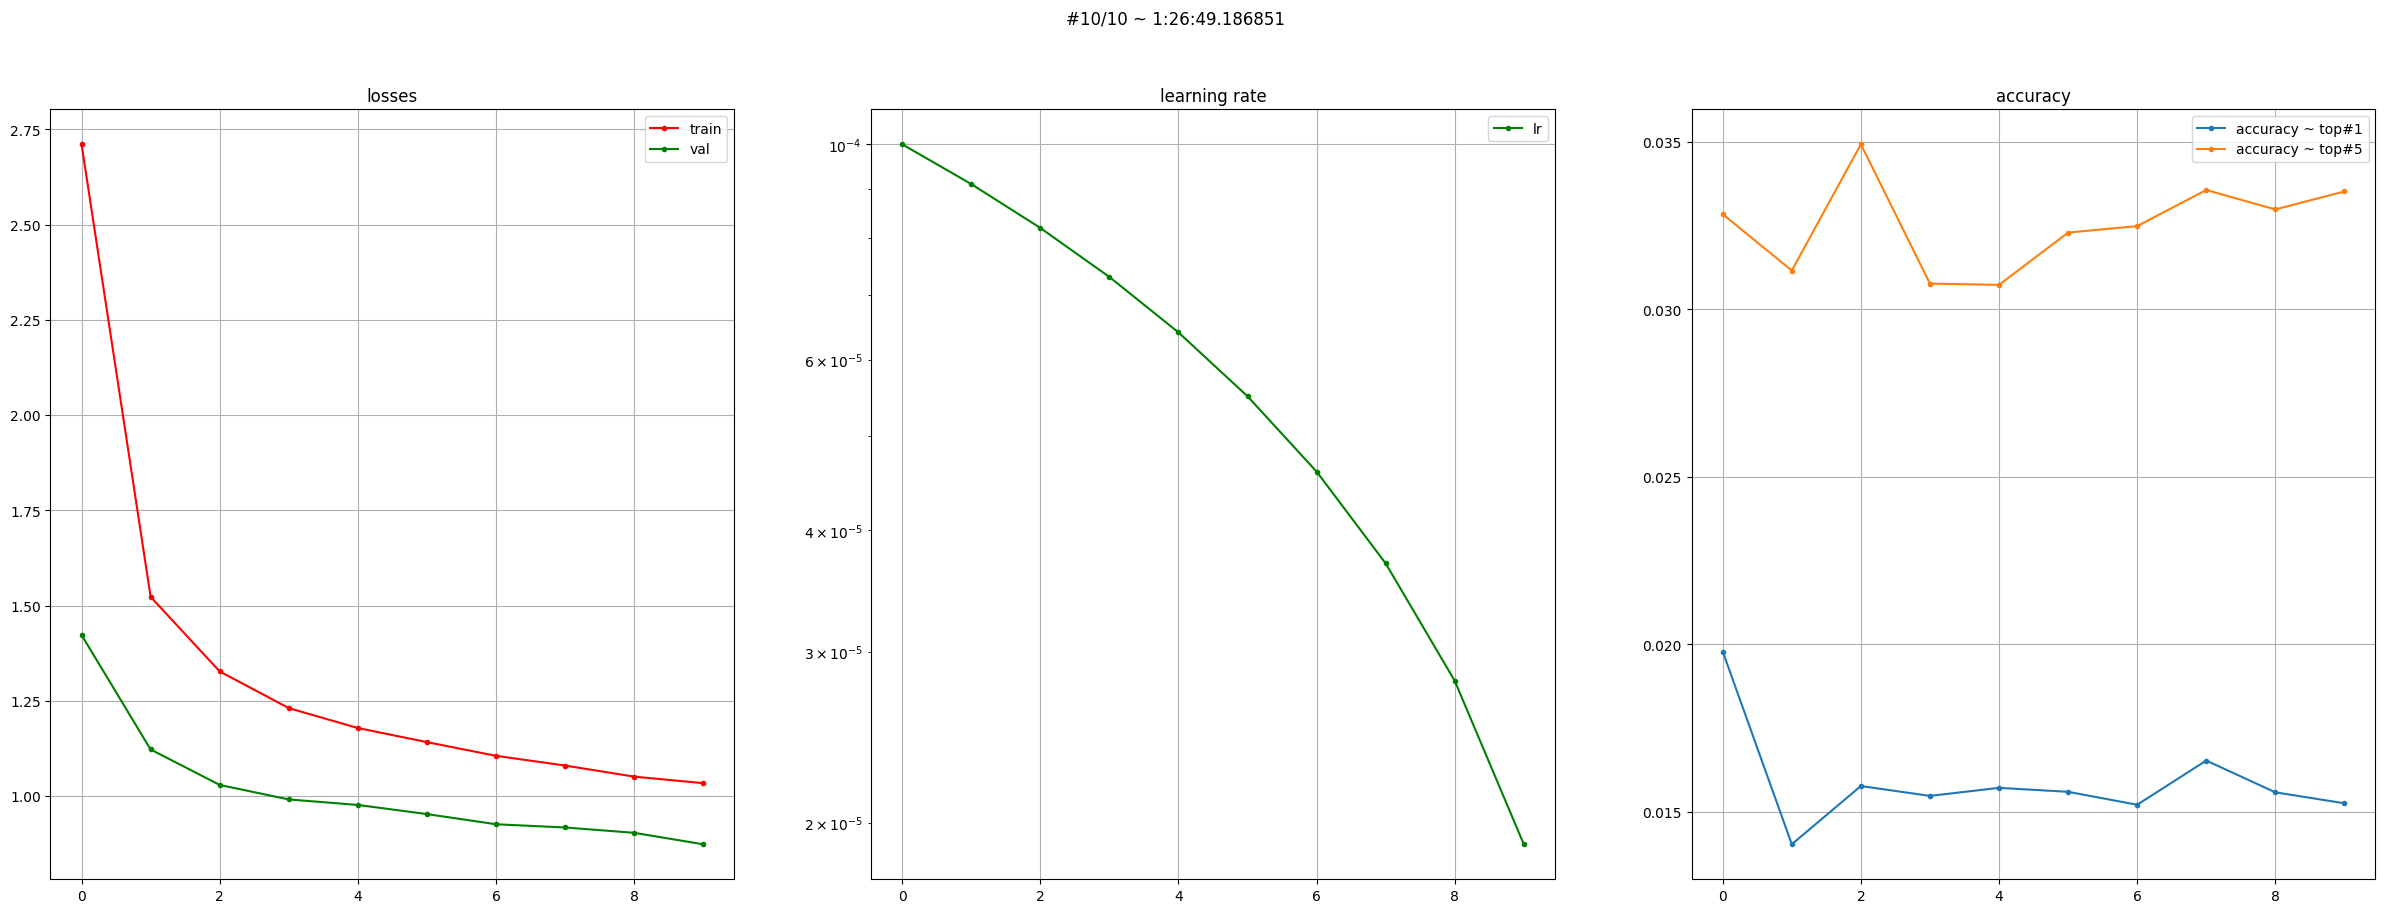

In [18]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from transformers import get_constant_schedule_with_warmup
from peft import LoraConfig

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["c_attn", "c_proj", "c_fc"],
    bias="none"
)

model_params = {
    'lora_config':lora_config,
    'first_rg_layer_num': 36,
    'hidden_size':1280,
}

optim_params = {
    'lr': 1e-4,
    'weight_decay': 0.01,
    'betas': (0.9, 0.999)
}


model, optimizer = create_model_and_optimizer(
    model_class=SteroidGPT,
    model_params={
        **model_params
    },
    optim_params={
        **optim_params
    },
    device=device
)

warmup_epochs = 3
total_epochs = 10


scheduler = LinearLR(
    optimizer,
    start_factor=1.0,
    end_factor=0.1,
    total_iters=total_epochs
)

# scheduler = SequentialLR(
#     optimizer,
#     schedulers=[
#         LinearLR(optimizer, 
#                  start_factor=0.00001, 
#                  end_factor=0.0001, 
#                  total_iters=warmup_epochs),
#         CosineAnnealingLR(optimizer, T_max=total_epochs - warmup_epochs)
#     ],
#     milestones=[warmup_epochs]
# )

criterion = nn.CrossEntropyLoss(ignore_index=0)

model, optimizer, losses = learning_loop(
    model = model,
    optimizer = optimizer,
    train_loader = dataloader_train,
    val_loader = dataloader_test,
    criterion = criterion,
    scheduler = scheduler,
    epochs = total_epochs,
    min_lr = None,
    val_every = 1,
    draw_every = 1,
    separate_show = False,
    metric_names = {
        "accuracy": {"top": [1, 5], "plot_id": 1},
    },
    chkp_folder = "./chkp",
    model_name = "default",
)

In [ ]:
def wrap_text(text, max_width):
    words = text.split(" ")
    result = [[words[0]]]
    for word in words[1:]:
        if len(" ".join(result[-1])) + len(word) + 1 > max_width:
            result[-1] = " ".join(result[-1])
            result.append([])
        result[-1].append(word)
    result[-1] = " ".join(result[-1])
    return "\n".join(result)


for input_ids, attention_mask, labels in dataloader_test:
    res = model.generate_from_batch(
        input_ids=input_ids.to(device),
        attention_mask=attention_mask.to(device),
        max_new_tokens=200,
        temperature=0.8,
        top_p=0.9
    )

    #label = model.tokenizer.batch_decode(labels, skip_special_tokens=False)
    print(model.tokenizer.batch_decode(input_ids, skip_special_tokens=False))
    print(res)
    break

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


["<META>\nVideo Title: BLACK PANTHER 3 ANNOUNCEMENT\nVideo Description: Black Panther 3 Announcement. Black Panther 3 Teaser, Avengers Doomsday Trailer connection, New T'ch\nChannel Title: Emergency Awesome\nChannel Description: All the best House Of The Dragon Game Of Thrones, The Mandalorian, Batman, Avengers and Marvel Movie\n\n<TEXT>\nHere's my new Black Panther 3 video, post all your predictions in the comments! Here's my Avengers Doomsday Trailer video too! https://www.youtube.com/watch?v=6KR_FGAuw4g&t=0s\n\n<REPLY>\nyou should do this agian", "<META>\nVideo Title: This game looks INSANE..\nVideo Description: Asmongold reacts to Mortal Shell 2.\n► Asmongold's Twitch: https://www.twitch.tv/zackrawrr\n► Asmongol\nChannel Title: Asmongold TV  \nChannel Description: The official Asmongold channel for all of his stream content (Highlights, Competitions, Reactions & \n\n<TEXT>\nI know how the UI looks is not THAT important but this one is perfect anyway.\n\n<REPLY>\nLmao get good<|endo

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import get_constant_schedule_with_warmup
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from transformers import get_constant_schedule_with_warmup
from peft import LoraConfig

model_name = "lora_30"
checkpoint = torch.load(os.path.join("./chkp", f"{model_name}.pt"), weights_only=False)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["c_attn", "c_proj", "c_fc"],
    bias="none"
)

model_params = {
    'lora_config':lora_config,
    'first_rg_layer_num': 30,
    'hidden_size':1280,
}

optim_params = {
    'lr': 1e-4,
    'weight_decay': 0.01,
    'betas': (0.9, 0.999)
}


model, optimizer = create_model_and_optimizer(
    model_class=SteroidGPT,
    model_params={
        **model_params
    },
    optim_params={
        **optim_params
    },
    device=device
)

warmup_epochs = 3
total_epochs = 8


scheduler = LinearLR(
    optimizer,
    start_factor=1.0,
    end_factor=0.1,
    total_iters=total_epochs
)


criterion = nn.CrossEntropyLoss(ignore_index=0)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
epoch = checkpoint['epoch']
losses = checkpoint['losses']

Loading weights: 100%|██████████| 436/436 [00:00<00:00, 14377.72it/s]


## **Результаты**

### LoRa + 18 последних слоев

In [18]:
for input_ids, attention_mask, labels in dataloader_test:
    

    res = model.generate_from_batch(
        input_ids=input_ids.to(device),
        attention_mask=attention_mask.to(device),
        max_new_tokens=200,
        temperature=0.8,
        top_p=0.9
    )

    for input, res in zip(model.tokenizer.batch_decode(input_ids, skip_special_tokens=False), res):
        print(input)
        print(res)
        print("\n")

    break

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


<META>
Video Title::I Survived 100 Hours as a cave dweller in Rust...
Video Description::Check out the fantasic Division Resurgence right here! https://tdr-wwl.onelink.me/3G20/Willjum

WATCH THE PREVIOUS CHAPTER HERE https://youtu.be/4gu
Channel Title::Willjum
Channel Description::A solo
 

<TEXT>
Could u parachute down the cave instead of dying always?
<REPLY>
Yes🤠🤠🤠<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endo

### LoRa + последние 5 слоев:

In [ ]:
text = '''<META>
Video Title: BLACK PANTHER 3 ANNOUNCEMENT
Video Description: Black Panther 3 Announcement. Black Panther 3 Teaser, Avengers Doomsday Trailer connection, New T'ch
Channel Title: Emergency Awesome
Channel Description: All the best House Of The Dragon Game Of Thrones, The Mandalorian, Batman, Avengers and Marvel Movie

<TEXT>'''

tokens = tokenizer(
    text,
    truncation=True,
    max_new_tokens=200,
    padding=False,
    return_tensors="pt"
)

input_ids = tokens["input_ids"]
attention_mask = tokens["attention_mask"]

print(input_ids.shape)
print(attention_mask.shape)

res = model.generate_from_batch(
    input_ids=input_ids.to(device),
    attention_mask=attention_mask.to(device),
    max_new_tokens=200,
    temperature=0.8,
    top_p=0.9
)

print(text)
print(res)



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


torch.Size([1, 71])
torch.Size([1, 71])
<META>
Video Title: BLACK PANTHER 3 ANNOUNCEMENT
Video Description: Black Panther 3 Announcement. Black Panther 3 Teaser, Avengers Doomsday Trailer connection, New T'ch
Channel Title: Emergency Awesome
Channel Description: All the best House Of The Dragon Game Of Thrones, The Mandalorian, Batman, Avengers and Marvel Movie

<TEXT>
["\n\u200b@joehambres5 gng, why are you giving your grocery list and asking the directions to the store. If you know what I am, and I'm not a vegetarian I'll just skip the grocery list. Also, why does this comment have so many likes? 😅😂😂 why do people have so much hate in their comments?? 😂😃😂 it&#39;s not blind anger, you just want to chime in and tell me how I am failing as a human because of my SR, which I suppose is fair. Yeah, I do. I just do. You just kind of keep going back because it&'s so hard to do it manually. Yeah. It&# 39;s true. My first upload was at 4am PST, and my first view was 0.001 seconds. 💔😁😁 my firs

In [36]:
text += res[0]  + "\n<REPLY>"

tokens = tokenizer(
    text,
    truncation=True,
    max_new_tokens=200,
    padding=False,
    return_tensors="pt"
)

input_ids = tokens["input_ids"]
attention_mask = tokens["attention_mask"]

print(input_ids.shape)
print(attention_mask.shape)

res = model.generate_from_batch(
    input_ids=input_ids.to(device),
    attention_mask=attention_mask.to(device),
    max_new_tokens=200,
    temperature=0.8,
    top_p=0.9
)

print(text)
print(res)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


torch.Size([1, 276])
torch.Size([1, 276])
<META>
Video Title: BLACK PANTHER 3 ANNOUNCEMENT
Video Description: Black Panther 3 Announcement. Black Panther 3 Teaser, Avengers Doomsday Trailer connection, New T'ch
Channel Title: Emergency Awesome
Channel Description: All the best House Of The Dragon Game Of Thrones, The Mandalorian, Batman, Avengers and Marvel Movie

<TEXT>
@_HOLYHOL YEAH💯💥💊💬💞💎💏💭💪💮💰💶💷💸💹💻💼💽💿

idem
@thespecialistshow I have a real question about the future of The show, if they make more episodes like the ones they did in the past will it be better or worse, or will it just be a different story?
@brianjames87 no, I think it's going to be the same story. The reason why they keep doing it is because it's FUN. It's entertaining. They need to keep doing more episodes because they love doing it and it's fun.

’’

mizuki, I just wanna know how you are going to tackle the future? Are you planning on
<REPLY>
["\n@mizkuizuki Yeah I'm gonna tackle the past. It will be a story that I t

### Только LoRa (лучший результат)

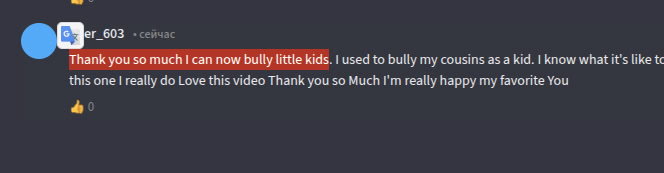

😭